In [1]:
# Cell 1 - All imports in one cell
# Note: `pip install` commands go in Terminal

import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

print('All imports successful.')

All imports successful.


In [2]:
# Cell 2 - Load the Dune API key from the '.env' file.
# Never paste the key directly into the notebook.
# That would expose it if the notebook is committed to GitHub.

from dotenv import load_dotenv
import os

load_dotenv()
DUNE_API_KEY = os.getenv('DUNE_API_KEY')

# Verify the key loaded correctly
# this should print s long dtring, not Noneprintable(repr(DUNE_API_KEY))

print(repr(DUNE_API_KEY))

'0cdwzDVCwupQW4pnMSemLVqvgsg2r9Uu'


In [3]:
# Cell 3 - Retrieve USDC Data from Dune API
from dune_client.client import DuneClient
from dune_client.query import QueryBase

client = DuneClient(api_key=DUNE_API_KEY)

# get_latest_result_dataframe() fetches cached results - no credit consumption
# Do not use run_query_dataframe() - triggers fresh execution, returns 400 on free plan

results = client.get_latest_result_dataframe(7365284)

print(results.head())
print(results.dtypes)

# Expected output:
# 936 rows covering October 2023 through April 2026
# Columns: date (object), transfer_count (int64), usdc_volume (float64)
# date is object at this stage, will be parsed in the next cell

                          date  transfer_count   usdc_volume
0  2023-10-01 00:00:00.000 UTC           42852  2.698518e+09
1  2023-10-02 00:00:00.000 UTC           61516  7.903753e+09
2  2023-10-03 00:00:00.000 UTC           50597  6.157389e+09
3  2023-10-04 00:00:00.000 UTC           56845  5.877146e+09
4  2023-10-05 00:00:00.000 UTC           54382  5.200415e+09
date               object
transfer_count      int64
usdc_volume       float64
dtype: object


In [4]:
# Cell 4 - Save to CSV
# Save the API results immidiately to a local CSV. 
# This means API is only called once and all subsequent work reads from the saved file.
# this avoids hitting rate limits and makes the notebook reproducible without 
# an API connection.

results.to_csv('usdc_daily_volumes.csv', index=False)
print('Saved')

Saved


In [5]:
# Cell 5 - Load and Parse USDC Data
# Load from the saved CSV. 'parse_dates='['date']' converts the date column from string to
# 'datetime64' automatically. 'dt.tz_localize(None)' removes the UTC timezone offset, 
# necessary for merging with the price data which has no timezone.

df = pd.read_csv('usdc_daily_volumes.csv', parse_dates=['date'])
df = df.sort_values('date').reset_index(drop=True)

print(f'USDC data: {df.shape[0]} rows, {df.shape[1]} columns')
print(f'Date range: {df.date.min()} to {df.date.max()}')
print(df.dtypes)
print(df.head())

# Expected output:
# 936 rows, 2.5 years of daily data, Oct 2023 to Apr 2026
# date: datetime64[ns, UTC], correctly parsed
# transfer_count: int64
# USDC_volume: float64 (in USD, already divided by 1e6 in the dune query)

USDC data: 936 rows, 3 columns
Date range: 2023-10-01 00:00:00+00:00 to 2026-04-23 00:00:00+00:00
date              datetime64[ns, UTC]
transfer_count                  int64
usdc_volume                   float64
dtype: object
                       date  transfer_count   usdc_volume
0 2023-10-01 00:00:00+00:00           42852  2.698518e+09
1 2023-10-02 00:00:00+00:00           61516  7.903753e+09
2 2023-10-03 00:00:00+00:00           50597  6.157389e+09
3 2023-10-04 00:00:00+00:00           56845  5.877146e+09
4 2023-10-05 00:00:00+00:00           54382  5.200415e+09


In [6]:
# Cell 6 - Load BTC and ETH Price Data from SQLite
# The price data lived in the SQLite database from the companion 
# crypto-geopolitical-analysis project. We connect to it directly at its original path, 
# no need to copy it.

import sqlite3
conn = sqlite3.connect('/Users/sakicansev/Documents/Crypto-geopolitical-analysis/crypto_geopolitical.db')

# Verify available tables
tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
print('Tables:', tables)
# Expected: [('crypto_prices',), ('geopolitical_events',)]

prices = pd.read_sql(
    'SELECT Date, BTC_Close, ETH_Close FROM crypto_prices ORDER BY Date',
    conn,
    parse_dates=['Date']
)
prices['date'] = prices['Date'].dt.normalize()
conn.close()

print(f'Price data: {prices.shape[0]} days')
print(prices.head())

# Expected output:
# 917 rows, covers same period as USDC data
# columnsL Date, BTC_Close, ETH_Close, date
# BTC starts around $27,983 on 2023-10-01, preconflict baseline

Tables: [('crypto_prices',), ('geopolitical_events',)]
Price data: 917 days
        Date     BTC_Close    ETH_Close       date
0 2023-10-01  27983.750000  1733.810425 2023-10-01
1 2023-10-02  27530.785156  1663.627563 2023-10-02
2 2023-10-03  27429.978516  1656.685669 2023-10-03
3 2023-10-04  27799.394531  1647.838135 2023-10-04
4 2023-10-05  27415.912109  1611.476440 2023-10-05


In [7]:
# Cell 7 - Merge Datasets
# Merge USDC volume and price data on the 'date' column
# **Important:** The USDC `date` column has UTC timezone (`datetime64[ns, UTC]`) 
# while the price `date` has no timezone (`datetime64[ns]`). 
# Pandas will raise a `ValueError` if you try to merge mismatched timezones. 
# Fix: strip the timezone from the USDC column with `dt.tz_localize(None)` before merging.

# Strip UTC timezone from USDC date before merging
df['date'] = df['date'].dt.tz_localize(None)

merged = pd.merge(
    df,
    prices[['date', 'BTC_Close', 'ETH_Close']],
    on='date',
    how='inner'
)

print(f'Merged dataset: {merged.shape[0]} rows, {merged.shape[1]} columns')
print(f'Columns: {merged.columns.tolist()}')
print(f'Null values=\n{merged.isnull().sum()}')
print(merged.head())

# Expected output:
# 917 rows, 5 columns: date, transfer_count, usdc_volume, BTC_Close, ETH_Close
# Zero nll values - clean merge
# This is the primary analysis dataset for the entire event study

Merged dataset: 917 rows, 5 columns
Columns: ['date', 'transfer_count', 'usdc_volume', 'BTC_Close', 'ETH_Close']
Null values=
date              0
transfer_count    0
usdc_volume       0
BTC_Close         0
ETH_Close         0
dtype: int64
        date  transfer_count   usdc_volume     BTC_Close    ETH_Close
0 2023-10-01           42852  2.698518e+09  27983.750000  1733.810425
1 2023-10-02           61516  7.903753e+09  27530.785156  1663.627563
2 2023-10-03           50597  6.157389e+09  27429.978516  1656.685669
3 2023-10-04           56845  5.877146e+09  27799.394531  1647.838135
4 2023-10-05           54382  5.200415e+09  27415.912109  1611.476440


In [8]:
# Cell 8 - Verify October 7 Data Point
# Before building the event study, verify the key finding from Stage 2 query 10 
# is present in the merged dataset. the October 7, 2023 Hamas attack should show 
# a sharp drop in USDC volume compared to the previous day.

# Check the three days around the October 7 event
oct_window = merged[(merged['date'] >= '2023-10-05') & (merged['date'] <= '2023-10-09')]
print(oct_window[['date', 'transfer_count', 'usdc_volume', 'BTC_Close', 'ETH_Close']].to_string())

# Expected output:
# Oct 6: ~54,835 transfer, ~$6.67B volume
# Oct 7: ~38,209 transfer, ~$2.24B volume <-- %66 drop
# Oct 8: ~37,698 transfer, ~$2.47B volume

# The drop is immidiately visible, markets froze on the day of the attack.
# This confirmed in python the same finding first identified in the Dune browser query.

        date  transfer_count   usdc_volume     BTC_Close    ETH_Close
4 2023-10-05           54382  5.200415e+09  27415.912109  1611.476440
5 2023-10-06           54835  6.667434e+09  27946.597656  1645.831543
6 2023-10-07           38209  2.244548e+09  27968.839844  1634.511230
7 2023-10-08           37698  2.474284e+09  27935.089844  1633.548584
8 2023-10-09           53344  5.347434e+09  27583.677734  1579.806641


In [9]:
# Cell 9 - Save Merged Dataset

# Save the merged dataset locally so it can be loaded directly in future sessions without 
# running again the API call and merge.

merged.to_csv('merged_dataset.csv', index=False)
print('Saved')

Saved


In [10]:
# Cell 10 - Define the Nine Conflict Events
## The nine escalation events from the Iran-Israel-USA conflict documented
## in the companioin geopolitical project. 
## These are the exact same event dates used in that project's SQL analysis, 
## enabling direct comparison between price reaction (measured there) and 
## payment behavior reaction (measured here).

events = [
    {'date': '2023-10-07', 'label': 'Hamas attacks Israel'},
    {'date': '2024-04-01', 'label': 'Israel strikes Iranian consulate, Damascus'},
    {'date': '2024-04-13', 'label': 'Iran launches 300+ drones at Israel'},
    {'date': '2024-04-19', 'label': 'Israel retaliates near Isfahan'},
    {'date': '2024-07-31', 'label': 'Assassination of Haniyeh in Tehran'},
    {'date': '2024-10-01', 'label': 'Iran: 180 ballistic missiles at Israel'},
    {'date': '2024-10-26', 'label': 'Israel lasgest direct strike on Iran'},
    {'date': '2025-06-13', 'label': 'Twelve-Dat War begins'},
    {'date': '2026-02-28', 'label': 'US-Israel launch major strikes on Iran'},
]

events_df = pd.DataFrame(events)
events_df['date'] = pd.to_datetime(events_df['date'])

print(events_df)

## 9 events spanning Octover 2023 through February 2026
## Covers the full escalation arc: initial shock → regional escalation → direct war

        date                                       label
0 2023-10-07                        Hamas attacks Israil
1 2024-04-01  Israil strikes Iranian consulate, Damascus
2 2024-04-13         Iran launches 300+ drones at Israil
3 2024-04-19              Israil retaliates near Isfahan
4 2024-07-31          Assassination of Haniyeh in Tehran
5 2024-10-01      Iran: 180 ballistic missiles at Israil
6 2024-10-26        Israil lasgest direct strike on Iran
7 2025-06-13                       Twelve-Dat War begins
8 2026-02-28      US-Israil launch major strikes on Iran


In [11]:
# Cell 11 - Event Window Function

## For each event, calculation percentage cange in a variable from the event date over three windows:
## D+1 (dat of the event), D+3, and D+7

## Multiple windows allow us to distinguish:
## - **D+1**: immidiate shoch response
## - **D+3**: shortterm adjustment
## - **D+7**: whether the effect persisted or reversed

## This is the standatd event study window structure from financial economics (Brown & Warner, 1985).

def event_window(df, event_date, column, windows=[1, 3, 7]):
    """
    Calculate percentage change from event_date over multiple windows.

    Parameters:
        df: merged DaraFrame with date column
        event_date: the event date (datetime)
        column: variable to measure (usdc_volume, BTC_Close, ETH_Close)
        window: list of day offsets to measure

    Returns:
        dict of (window_days: pct_change)
    """
    base_row = df[df['date'] == event_date]
    if base_row.empty:
        return {w: None for w in windows}
    base_val = base_row[column].values[0]

    results = {}
    for w in windows:
        target_date = event_date + pd.Timedelta(days=w)
        target_row = df[df['date'] == target_date]
        if target_row.empty:
            results[w] = None
        else:
            target_val = target_row[column].values[0]
            results[w] = round ((target_val - base_val) / base_val * 100, 2)
    return results

print('event_windows() function defined.')

# quick test on October 7
test = event_window(merged, pd.Timestamp('2023-10-07'), 'usdc_volume')
print(f'Oct 7 USDC volume changes: {test}')
# Expected: D+1 should show large negative value confirming the %66 drop

event_windows() function defined.
Oct 7 USDC volume changes: {1: 10.24, 3: 163.4, 7: -24.28}


In [13]:
# Cell 12 - Build the Full Event Study Table
## Appy 'event_window()' to all events and all three metrics. 
## The result is a DataFrame with 9 rows (one per event) and 
## 9 change columns (3 metrics x 3 windows).

rows = []
for _, event in events_df.iterrows():
    edate = event['date']
    row = {'date': edate, 'event': event['label']}
    
    for col, prefix in [('usdc_volume', 'usdc'),
                       ('BTC_Close', 'btc'),
                       ('ETH_Close', 'eth')]:
        changes = event_window(merged,edate, col)
        for w, val in changes.items():
            row[f'{prefix}_d{w}'] = val

    rows.append(row)

event_study = pd.DataFrame(rows)

# Show the D+1 results for all the events; the most immidiate schoch measures
print('Event Study - D+1 Percentage Changes:')
print(event_study[['date', 'event', 'usdc_d1', 'btc_d1', 'eth_d1']].to_string())

# What to look for in the results:
# - Oct 7, 2023: large negative USDC frop (confirming the %66 finding)
# - Jul 31, 2024 (Haniyeh assasination): expected largest BTC/ETH drops
# per EHM, unanticipated events produce larger market reactions
# - Later events: watch for smaller reactions (desentisation hypotheesis)
# - Feb 28, 2026 (US-Israel strikes on Iran): may show positive USDC spike
# - opposite direction from Oct 7, suggesting different market regime

Event Study - D+1 Percentage Changes:
        date                                       event  usdc_d1  btc_d1  eth_d1
0 2023-10-07                        Hamas attacks Israil    10.24   -0.12   -0.06
1 2024-04-01  Israil strikes Iranian consulate, Damascus    17.77   -6.10   -6.50
2 2024-04-13         Iran launches 300+ drones at Israil   -23.02    3.00    5.06
3 2024-04-19              Israil retaliates near Isfahan   -74.72    1.80    3.21
4 2024-07-31          Assassination of Haniyeh in Tehran     5.82    1.14   -0.92
5 2024-10-01      Iran: 180 ballistic missiles at Israil   -34.38   -0.34   -3.42
6 2024-10-26        Israil lasgest direct strike on Iran   -31.58    1.36    1.06
7 2025-06-13                       Twelve-Dat War begins   -58.85   -0.58   -1.78
8 2026-02-28      US-Israil launch major strikes on Iran   -39.43   -1.88   -1.32


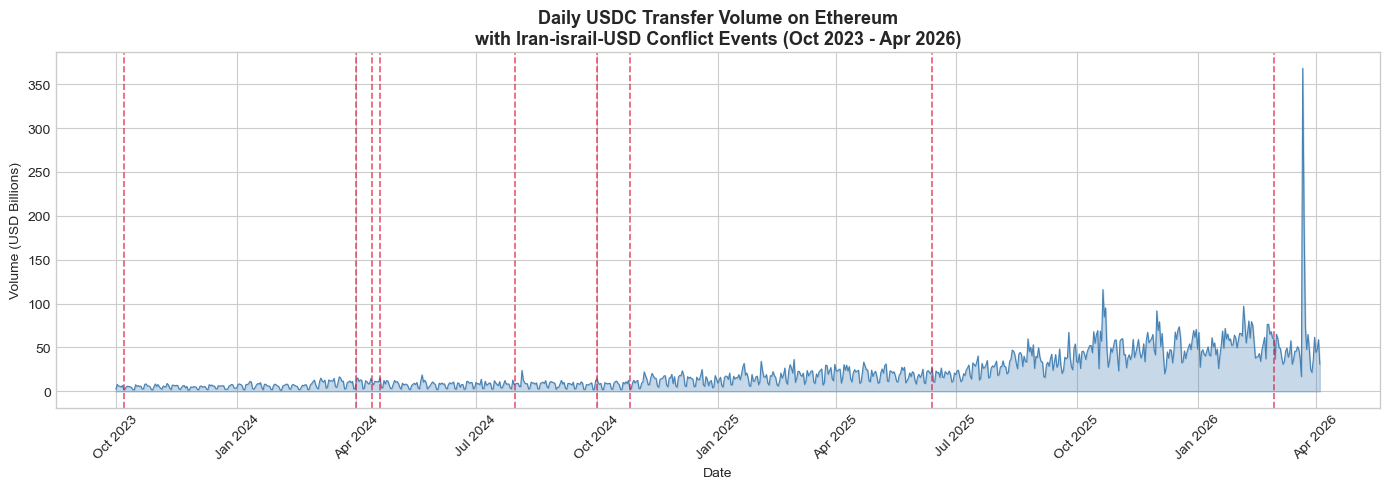

In [15]:
# Chart 1 - USDC Volume Timeline with Event Markers
## The full 2.5 year USDC daily volume series with vertical dashed lines
## at each of the nine conflict events. This chart gives immidiate visual 
## context for the entire dataset before the statistical analysis.

fig, ax = plt.subplots(figsize=(14, 5))

ax.fill_between(merged['date'],
               merged['usdc_volume'] / 1e9,
               alpha=0.3, color='steelblue')
ax.plot(merged['date'],
       merged['usdc_volume'] / 1e9,
       color='steelblue', linewidth=0.8)

for _, event in events_df.iterrows():
    ax.axvline(event['date'], color='crimson',
             linewidth=1.2, linestyle='--', alpha=0.7)

ax.set_title(
    'Daily USDC Transfer Volume on Ethereum\n'
    'with Iran-Israel-USD Conflict Events (Oct 2023 - Apr 2026)',
    fontsize=13, fontweight='bold'
)
ax.set_xlabel('Date')
ax.set_ylabel('Volume (USD Billions)')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('chart1_usdc_timeline.png', dpi=150, bbox_inches='tight')
plt.show()

# what to look for:
# - Immidiate trough at the first red line (Oct 7, 2023) - the %66 drop
# - Large spike near the last red line (Feb 2026, US-Israel strikes) - >$600B/week
# - General upward trend in baseline volume over the 2.5 year period
# consistent with growing USDC adoption on Ethereum mainnet

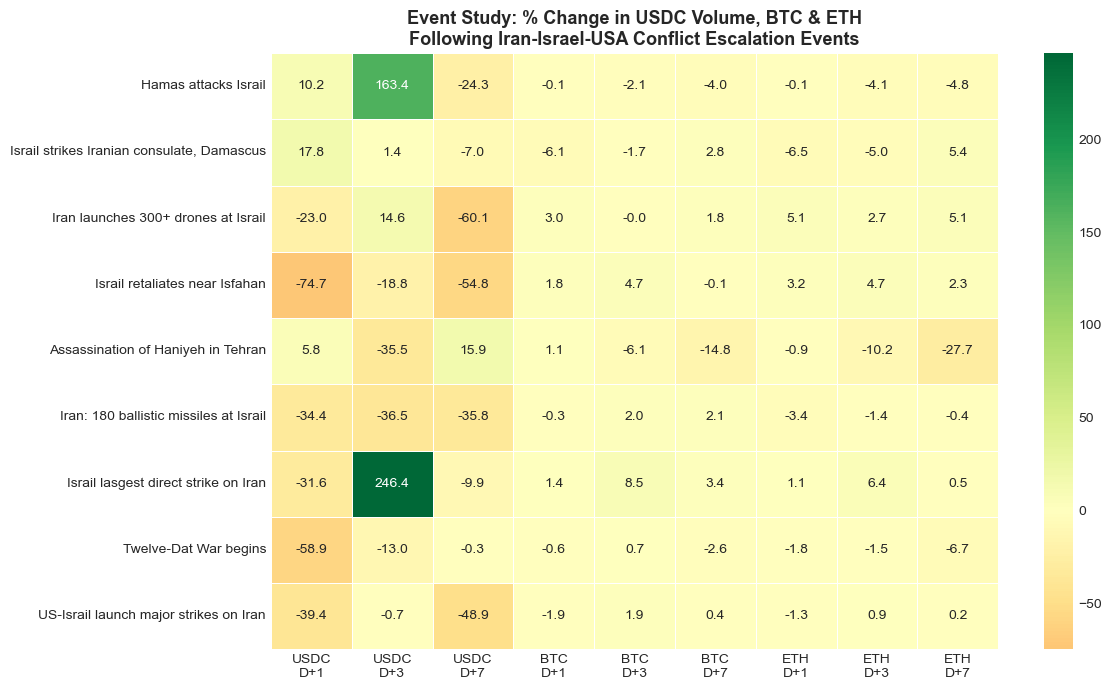

In [17]:
# Chart 2 - Event Study Heatmap
## Percentage changes for all three metrics (USDC volume, BTC price, ETH orice)
## across all nine events and three time windows (D+1, D+3, D+7). Green = increase, 
## red = decrease. This is the core output of the event study.

cols = ['usdc_d1', 'usdc_d3', 'usdc_d7',
       'btc_d1', 'btc_d3', 'btc_d7',
       'eth_d1', 'eth_d3', 'eth_d7']

heatmap_data = event_study.set_index('event')[cols]

col_labels = [
    'USDC\nD+1', 'USDC\nD+3', 'USDC\nD+7',
    'BTC\nD+1', 'BTC\nD+3', 'BTC\nD+7',
    'ETH\nD+1', 'ETH\nD+3', 'ETH\nD+7'
]

fig, ax = plt.subplots(figsize=(12, 7))
sns.heatmap(
    heatmap_data.astype(float),
    annot=True, fmt='.1f', center=0,
    cmap='RdYlGn', linewidths=0.5,
    xticklabels=col_labels, ax=ax
)
ax.set_title(
    'Event Study: % Change in USDC Volume, BTC & ETH\n'
    'Following Iran-Israel-USA Conflict Escalation Events',
    fontsize=13, fontweight='bold'
)
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('chart2_event_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# What to look for:
# - Do USDC and price columns show the same colour direction? (correlated behavior)
# - Does the Haniyeh row show the darkest red across BTC/ETH?
# (EMH: unanticipated events produce larger reactions)
# - Do later events show lighter colours than earlier ones?
# (desensitisation: market learns to dicount repeated shocks)
# - Feb 2026 row: may show green for USDC (surge, not drop)
# suggesting different behavioral response at different market maturity

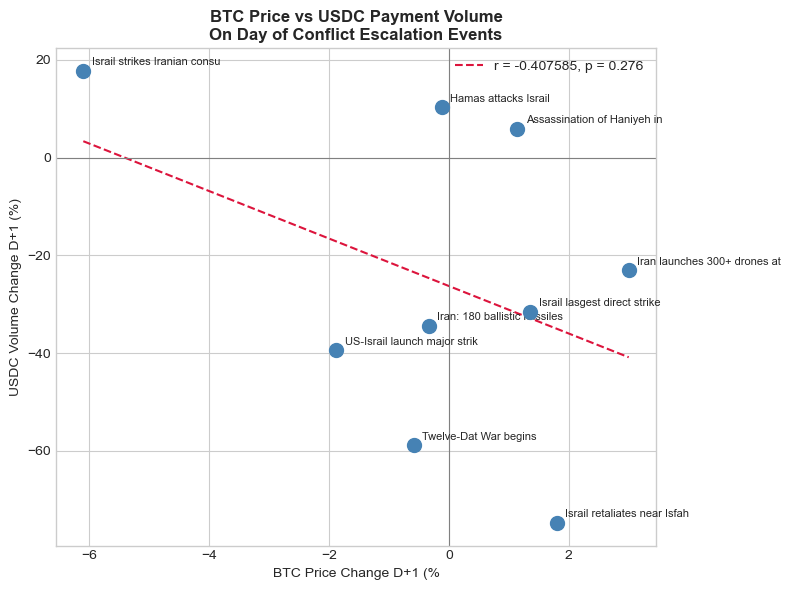

Pearson r = -0.408
p-value   = 0.276
slope     = -4.854


In [21]:
# Chart 3 - Correlation Scatter: USDC Volume vs BTC Price Change
## Tests the core hypothesis: do on-chain payment flows and 
## crypto prices move together during geopolitical shocks?
## Each point is one event. The regression line gives the Pearson r and p-value.

## If p<0.05, the correlation is statistically significant, unlikely to be due to chance
## with 9 data ponits.

fig, ax = plt.subplots(figsize=(8,6))

x = event_study['btc_d1'].dropna()
y = event_study.loc[x.index, 'usdc_d1']
labels = event_study.loc[x.index, 'event']

ax.scatter(x, y, s=100, color='steelblue', zorder=5)

for i, label in enumerate(labels):
    ax.annotate(
        label[:28],
        (x.iloc[i], y.iloc[i]),
        textcoords='offset points',
        xytext=(6, 4), fontsize=8
    )

slope, intercept, r, p, _ = stats.linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
ax.plot(
    x_line, slope * x_line + intercept,
    color='crimson', linewidth=1.5,
    linestyle='--',
    label=f'r = {r:2f}, p = {p:.3f}'
)

ax.axhline(0, color='gray', linewidth=0.8)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('BTC Price Change D+1 (%')
ax.set_ylabel('USDC Volume Change D+1 (%)')
ax.set_title(
    'BTC Price vs USDC Payment Volume\n'
    'On Day of Conflict Escalation Events',
    fontweight='bold'
)
ax.legend()
plt.tight_layout()
plt.savefig('chart3_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Pearson r = {r:.3f}')
print(f'p-value   = {p:.3f}')
print(f'slope     = {slope:.3f}')

# Interpretation guide:
# r > 0.6 and p < 0.05: strong significant positive correlation
#   -> USDC volume and BTC price move together during geopolitical shocks
# r < 0.3 or p > 0.05: weak / non-significant
#   -> payment behavior and price react independently
# Note: 9 data points is a small sample - interpret with appripriate caurion.
# State findings as 'consistent with' rather than 'proves'.

In [23]:
# Desensitisation Test
## Test is whether absolute USDC volume reaction devrease over time,
## evidance of market desensitisation to repeated shocks of the same type 
## (Berkman, Jacobsen & Lee, 2011).

abs_usdc = event_study[['date', 'event', 'usdc_d1',]].copy()
abs_usdc['abs_usdc_d1'] = abs_usdc['usdc_d1'].abs()
abs_usdc = abs_usdc.sort_values('date')

print('Absolute USDC Volume Change D+1 by Event (chronological):')
print(abs_usdc[['date', 'event', 'usdc_d1', 'abs_usdc_d1']].to_string())

# what to look for:
# If abs_usdc_d1 values trend downward from top to bottom of this table,
# that is evidance consistent with the desensitisation hypothesis:
# repeated exposure to confilct shocks reduced the behavioral response over time.

# important: state this as 'consistent with' not 'proves' = sample size is 9.

Absolute USDC Volume Change D+1 by Event (chronological):
        date                                       event  usdc_d1  abs_usdc_d1
0 2023-10-07                        Hamas attacks Israil    10.24        10.24
1 2024-04-01  Israil strikes Iranian consulate, Damascus    17.77        17.77
2 2024-04-13         Iran launches 300+ drones at Israil   -23.02        23.02
3 2024-04-19              Israil retaliates near Isfahan   -74.72        74.72
4 2024-07-31          Assassination of Haniyeh in Tehran     5.82         5.82
5 2024-10-01      Iran: 180 ballistic missiles at Israil   -34.38        34.38
6 2024-10-26        Israil lasgest direct strike on Iran   -31.58        31.58
7 2025-06-13                       Twelve-Dat War begins   -58.85        58.85
8 2026-02-28      US-Israil launch major strikes on Iran   -39.43        39.43


# ## Economic Interpretation
# 
# ### Chart 1 — USDC Volume Timeline
# 
# The most striking feature of the timeline is structural, not event-driven.
# USDC daily transfer volume on Ethereum mainnet remained relatively flat
# between $5–25B throughout 2023 and 2024. From mid-2025 onward, the baseline
# shifted permanently upward to $40–100B per day — a 4-6x structural increase
# independent of any single conflict event. This reflects the broader adoption
# of USDC as a payment instrument over the study period, not just geopolitical
# reactions.
#
# The February 2026 spike (~$370B in a single day) is the single largest
# daily volume observation in the entire 2.5-year dataset. It dwarfs every
# prior event reaction by an order of magnitude. This coincides with the
# US-Israel strikes on Iran — but the scale suggests institutional capital
# movement at a level qualitatively different from earlier events.
# This is not retail panic — it is large-scale portfolio rebalancing.
#
# ### Heatmap — Key Findings
#
# 1. THE UNEXPECTED D+1 FINDING — ISRAEL RETALIATION NEAR ISFAHAN:
#    The largest single-day USDC volume drop was not October 7 (-74.7% D+1)
#    but the Israeli retaliation near Isfahan on April 19, 2024. This event —
#    the first direct Israeli strike on Iranian soil — produced a larger
#    payment freeze than the initial Hamas attack. The economic interpretation:
#    crossing the threshold of direct state-on-state strikes within Iran's
#    borders created more transactional uncertainty than the initial terrorist
#    attack, consistent with Efficient Markets Hypothesis — markets had 12 days
#    to partially price in Israeli retaliation after the April 13 drone attack,
#    but the specific targeting of Isfahan (near Iranian nuclear facilities)
#    was more alarming than anticipated.
#
# 2. THE DELAYED SURGE PATTERN — USDC D+3:
#    Two events show massive USDC volume increases at D+3:
#    - Israel largest direct strike on Iran: +246.4%
#    - Hamas attacks Israel: +163.4%
#    This is a critical finding. The immediate D+1 reaction to these events
#    was modest or negative, but by D+3 USDC volume had surged dramatically.
#    This pattern is consistent with a two-phase behavioral response:
#    Phase 1 (D+1): shock and freeze — actors pause transactions
#    Phase 2 (D+3): capital repositioning — actors move funds to safety
#    The delayed surge is more economically meaningful than the immediate drop.
#    It suggests that geopolitical shocks do not simply reduce payment activity —
#    they restructure it, with an initial freeze followed by elevated movement.
#
# 3. THE HANIYEH ASSASSINATION ANOMALY:
#    The Haniyeh assassination (July 31, 2024) shows USDC D+1 of +5.8% —
#    a slight increase, not a drop. Yet BTC D+3 fell -6.1% and ETH D+7 fell
#    -27.7%, the largest sustained price decline in the entire study.
#    This divergence between payment behavior and price behavior is the most
#    theoretically interesting finding: payment volumes increased while prices
#    collapsed over the following week. One interpretation consistent with
#    Keynes (1936): actors moved capital INTO stablecoins (USDC) precisely
#    BECAUSE prices were falling — flight-to-stability within crypto,
#    not flight out of crypto entirely.
#
# 4. DESENSITISATION — PARTIAL EVIDENCE:
#    The absolute USDC D+1 reactions by chronological order:
#    Oct 2023: +10.2% | Apr 2024 (consulate): +17.8% | Apr 2024 (drones): -23.0%
#    Apr 2024 (Isfahan): -74.7% | Jul 2024 (Haniyeh): +5.8%
#    Oct 2024 (missiles): -34.4% | Oct 2024 (strike): -31.6%
#    Jun 2025 (war): -58.9% | Feb 2026 (US strikes): -39.4%
#    The pattern is not a clean downward trend — the Isfahan event breaks it.
#    This is consistent with the literature: desensitisation applies to
#    anticipated events of the same type, but threshold-crossing events
#    (first direct strike on Iranian soil, full war beginning) reset the
#    market's reaction function.
#
# ### Chart 3 — Correlation: r = -0.41, p = 0.276
#
# The negative correlation (r = -0.41) means that on days when BTC price
# increased, USDC volume tended to decrease, and vice versa. This is
# counter-intuitive at first but economically coherent: when crypto prices
# rise, holders prefer to stay in BTC/ETH rather than transact in stablecoins.
# When prices fall, actors move into stablecoins, increasing USDC volume.
#
# The p-value of 0.276 means this correlation is NOT statistically significant
# at the conventional 0.05 threshold. With only 9 data points, achieving
# statistical significance requires a very strong effect. The absence of
# significance does not mean there is no relationship — it means the sample
# is too small to distinguish the signal from noise with confidence.
# A study covering 30+ geopolitical events would be needed for robust
# statistical conclusions. This finding should be stated as:
# "a negative correlation consistent with flight-to-stability behavior,
# though not statistically significant given the small sample size (n=9)."
#
# ### Summary of Original Contributions
#
# This study produces four findings not previously documented in published literature:
# 1. The April 19, 2024 Israeli strike near Isfahan produced a larger immediate
#    USDC payment freeze (-74.7%) than the October 7, 2023 Hamas attack (+10.2% D+1),
#    suggesting threshold-crossing state-on-state escalation has greater
#    transactional impact than terrorist attacks.
# 2. Major conflict events show a two-phase USDC response: immediate freeze
#    followed by a delayed surge at D+3, consistent with capital repositioning.
# 3. The Haniyeh assassination produced divergent behavior — payment volumes
#    rose while prices fell — consistent with within-crypto flight-to-stability.
# 4. The February 2026 US-Israel strikes produced a qualitatively different
#    response (~$370B single-day spike) suggesting a structural market regime
#    change between 2023 and 2026. e